In [ ]:
%%writefile leitor.py
from pathlib import Path
import os
import csv

try:
    BASE_DIR = Path(__file__).parent
except NameError:
    BASE_DIR = Path(os.getcwd())

DATASETS_DIR = BASE_DIR / "Datasets"

def listar_arquivos_dataset(subpasta: str):
    pasta = DATASETS_DIR / subpasta
    if not pasta.exists():
        raise FileNotFoundError(f"Pasta não encontrada: {pasta}")
    return list(pasta.iterdir())

def ler_txt(caminho: Path):
    with open(caminho, "r", encoding="utf-8") as f:
        return f.readlines()

def ler_csv(caminho: Path):
    with open(caminho, "r", encoding="utf-8") as f:
        return list(csv.reader(f))

def ler_csv_dict(caminho: Path):
    with open(caminho, "r", encoding="utf-8") as f:
        return list(csv.DictReader(f))

def ler_arquivo(subpasta: str, nome_arquivo: str):
    caminho = DATASETS_DIR / subpasta / nome_arquivo

    if not caminho.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho}")

    if caminho.suffix == ".txt":
        return ler_txt(caminho)

    if caminho.suffix == ".csv":
        return ler_csv(caminho)

    print(f"Tipo não suportado: {caminho.suffix}")
    return None

Overwriting leitor.py


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

from leitor import DATASETS_DIR

Junção dos arquivos processados numa única tabela

In [ ]:
'''
import os
import pandas as pd

# Pasta onde os arquivos processados (CSV) estão salvos
pasta_processados = "dados_processados"

# Lista todos os arquivos CSV nessa pasta e ordena alfabeticamente
arquivos_csv = sorted([
    os.path.join(pasta_processados, f)
    for f in os.listdir(pasta_processados)
    if f.endswith(".csv")
])

print("\n=== Arquivos a serem unificados ===")
for arq in arquivos_csv:
    print(f" - {arq}")

# Lista para armazenar DataFrames temporários
dfs = []
schema_base = None

for arquivo in arquivos_csv:
    try:
        df_temp = pd.read_csv(arquivo)

        # Verifica schema
        if schema_base is None:
            schema_base = list(df_temp.columns)
        else:
            if list(df_temp.columns) != schema_base:
                print(f"\nAVISO: O arquivo {arquivo} possui colunas diferentes!")
                print(f"Schema esperado: {schema_base}")
                print(f"Schema encontrado: {list(df_temp.columns)}")
                print("Tentando alinhar colunas automaticamente...\n")

                # Alinha colunas faltantes
                for col in schema_base:
                    if col not in df_temp.columns:
                        df_temp[col] = None  # preenche coluna ausente

                # remove colunas extras
                df_temp = df_temp[schema_base]

        dfs.append(df_temp)
        print(f"Carregado {arquivo} (shape: {df_temp.shape})")

    except Exception as e:
        print(f"Erro ao carregar {arquivo}: {e}")

# Verifica se ao menos 1 DF foi carregado
if len(dfs) == 0:
    raise RuntimeError("Nenhum CSV válido encontrado para unificação!")

# Concatena todos os DataFrames da lista em um único DataFrame
df_unificado = pd.concat(dfs, ignore_index=True)

print("\n=== RESULTADO FINAL ===")
print(f"Shape do dataset unificado: {df_unificado.shape}")
print(f"Total de arquivos unificados: {len(dfs)}")

# Salva o dataset unificado em CSV
arquivo_saida = os.path.join(pasta_processados, "dataset_final_unificado.csv")
df_unificado.to_csv(arquivo_saida, index=False)

print(f"\nArquivo unificado salvo em: {arquivo_saida}")
'''

'\nimport os\nimport pandas as pd\n\n# Pasta onde os arquivos processados (CSV) estão salvos\npasta_processados = "dados_processados"\n\n# Lista todos os arquivos CSV nessa pasta e ordena alfabeticamente\narquivos_csv = sorted([\n    os.path.join(pasta_processados, f)\n    for f in os.listdir(pasta_processados)\n    if f.endswith(".csv")\n])\n\nprint("\n=== Arquivos a serem unificados ===")\nfor arq in arquivos_csv:\n    print(f" - {arq}")\n\n# Lista para armazenar DataFrames temporários\ndfs = []\nschema_base = None\n\nfor arquivo in arquivos_csv:\n    try:\n        df_temp = pd.read_csv(arquivo)\n\n        # Verifica schema\n        if schema_base is None:\n            schema_base = list(df_temp.columns)\n        else:\n            if list(df_temp.columns) != schema_base:\n                print(f"\nAVISO: O arquivo {arquivo} possui colunas diferentes!")\n                print(f"Schema esperado: {schema_base}")\n                print(f"Schema encontrado: {list(df_temp.columns)}")\n   

Script Completo com Otimização Refinada e Padronização (para KNN)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import time

def converter_gtfs_tempo(tempo_str):
    """Converte string de tempo GTFS (ex: '25:30:00') para Timedelta."""
    return pd.to_timedelta(tempo_str, errors='coerce')

caminho_arquivo = DATASETS_DIR / "dataset_final_unificado.csv"
df = pd.read_csv(caminho_arquivo)


print(f"Registros totais carregados: {len(df)}")

df['arrival_time_td'] = converter_gtfs_tempo(df['arrival_time'].astype(str))
df['departure_time_td'] = converter_gtfs_tempo(df['departure_time'].astype(str))

df.dropna(subset=['arrival_time_td', 'departure_time_td'], inplace=True)
df.sort_values(by=['trip_id', 'stop_sequence'], inplace=True)

df['prev_departure_time_td'] = df.groupby('trip_id')['departure_time_td'].shift(1)
df['duracao_segmento_seg'] = (df['arrival_time_td'] - df['prev_departure_time_td']).dt.total_seconds()

df_model = df[df['duracao_segmento_seg'] > 0].copy()
df_model.dropna(subset=['duracao_segmento_seg'], inplace=True)

print(f"Registros válidos para modelagem após pré-processamento: {len(df_model)}")

base_date = pd.to_datetime('2000-01-01')
df_model['departure_timestamp'] = base_date + df_model['departure_time_td']

df_model['hour_of_day'] = df_model['departure_timestamp'].dt.hour
df_model['day_of_week'] = df_model['departure_timestamp'].dt.dayofweek

features = [
    'direction_id',
    'stop_sequence',
    'stop_lat',
    'stop_lon',
    'hour_of_day',
    'day_of_week'
]

if df_model['route_id'].dtype == 'object':
    df_model['route_id_encoded'] = df_model['route_id'].astype('category').cat.codes
    features.append('route_id_encoded')
else:
    features.append('route_id')

target = 'duracao_segmento_seg'

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
print(f"Tamanho do conjunto de teste: {len(X_test)} amostras")


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


results = {}


print("\n--- Otimizando DecisionTreeRegressor ---")
dt_params = {
    'max_depth': [10, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}
dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)
start_time = time.time()
dt_grid.fit(X_train, y_train)
end_time = time.time()
results['Decision Tree Otimizada'] = {
    'best_params': dt_grid.best_params_,
    'train_time': end_time - start_time,
    'rmse': np.sqrt(abs(dt_grid.best_score_)),
    'r2': dt_grid.cv_results_['mean_test_score'][dt_grid.best_index_]
}

y_pred_best_dt = dt_grid.best_estimator_.predict(X_test)
results['Decision Tree Otimizada']['test_rmse'] = np.sqrt(mean_squared_error(y_test, y_pred_best_dt))
results['Decision Tree Otimizada']['test_r2'] = r2_score(y_test, y_pred_best_dt)

print(f"Melhores parâmetros para Decision Tree: {dt_grid.best_params_}")
print(f"Decision Tree Otimizada - RMSE (Teste): {results['Decision Tree Otimizada']['test_rmse']:.2f} segundos")
print(f"Decision Tree Otimizada - R² (Teste): {results['Decision Tree Otimizada']['test_r2']:.2f}")


print("\n--- Otimizando RandomForestRegressor ---")


rf_params = {
    'n_estimators': [75, 100, 125],
    'max_depth': [15, 20, 25],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)
start_time = time.time()
rf_grid.fit(X_train, y_train)
end_time = time.time()
results['Random Forest Otimizada'] = {
    'best_params': rf_grid.best_params_,
    'train_time': end_time - start_time,
    'rmse': np.sqrt(abs(rf_grid.best_score_)),
    'r2': rf_grid.cv_results_['mean_test_score'][rf_grid.best_index_]
}

y_pred_best_rf = rf_grid.best_estimator_.predict(X_test)
results['Random Forest Otimizada']['test_rmse'] = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))
results['Random Forest Otimizada']['test_r2'] = r2_score(y_test, y_pred_best_rf)

print(f"Melhores parâmetros para Random Forest: {rf_grid.best_params_}")
print(f"Random Forest Otimizada - RMSE (Teste): {results['Random Forest Otimizada']['test_rmse']:.2f} segundos")
print(f"Random Forest Otimizada - R² (Teste): {results['Random Forest Otimizada']['test_r2']:.2f}")

print("\n--- Otimizando KNeighborsRegressor (com dados escalados) ---")
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}
knn_grid = GridSearchCV(KNeighborsRegressor(n_jobs=-1), knn_params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)
start_time = time.time()
knn_grid.fit(X_train_scaled, y_train)
end_time = time.time()
results['KNN Otimizado'] = {
    'best_params': knn_grid.best_params_,
    'train_time': end_time - start_time,
    'rmse': np.sqrt(abs(knn_grid.best_score_)),
    'r2': knn_grid.cv_results_['mean_test_score'][knn_grid.best_index_]
}

y_pred_best_knn = knn_grid.best_estimator_.predict(X_test_scaled) # USAR X_TEST_SCALED AQUI!
results['KNN Otimizado']['test_rmse'] = np.sqrt(mean_squared_error(y_test, y_pred_best_knn))
results['KNN Otimizado']['test_r2'] = r2_score(y_test, y_pred_best_knn)

print(f"Melhores parâmetros para KNN: {knn_grid.best_params_}")
print(f"KNN Otimizado - RMSE (Teste): {results['KNN Otimizado']['test_rmse']:.2f} segundos")
print(f"KNN Otimizado - R² (Teste): {results['KNN Otimizado']['test_r2']:.2f}")

print("\n--- Resumo Final dos Modelos Otimizados ---")
for model_name, metrics in results.items():
    print(f"\nModelo: {model_name}")
    print(f"  Melhores Parâmetros: {metrics['best_params']}")
    print(f"  Tempo de Otimização: {metrics['train_time']:.2f} segundos")
    print(f"  RMSE (Teste): {metrics['test_rmse']:.2f} segundos")
    print(f"  R² (Teste): {metrics['test_r2']:.2f}")

Registros totais carregados: 4716463
Registros válidos para modelagem após pré-processamento: 208770
Tamanho do conjunto de treino: 167016 amostras
Tamanho do conjunto de teste: 41754 amostras

--- Otimizando DecisionTreeRegressor ---
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Melhores parâmetros para Decision Tree: {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 20}
Decision Tree Otimizada - RMSE (Teste): 836.58 segundos
Decision Tree Otimizada - R² (Teste): 0.96

--- Otimizando RandomForestRegressor ---
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Melhores parâmetros para Random Forest: {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 75}
Random Forest Otimizada - RMSE (Teste): 826.47 segundos
Random Forest Otimizada - R² (Teste): 0.96

--- Otimizando KNeighborsRegressor (com dados escalados) ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Melhores parâmetros para KNN: {'n_neighbors': 

Script para Simular Frotas Autônomas Vamos usar o best_rf_model ja otimizado.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import time

def converter_gtfs_tempo(tempo_str):
    return pd.to_timedelta(tempo_str, errors='coerce')

df = pd.read_csv(DATASETS_DIR / "dataset_final_unificado.csv")

df = pd.read_csv(caminho_arquivo)

df['arrival_time_td'] = converter_gtfs_tempo(df['arrival_time'].astype(str))
df['departure_time_td'] = converter_gtfs_tempo(df['departure_time'].astype(str))
df.dropna(subset=['arrival_time_td', 'departure_time_td'], inplace=True)
df.sort_values(by=['trip_id', 'stop_sequence'], inplace=True)
df['prev_departure_time_td'] = df.groupby('trip_id')['departure_time_td'].shift(1)
df['duracao_segmento_seg'] = (df['arrival_time_td'] - df['prev_departure_time_td']).dt.total_seconds()
df_model = df[df['duracao_segmento_seg'] > 0].copy()
df_model.dropna(subset=['duracao_segmento_seg'], inplace=True)

base_date = pd.to_datetime('2000-01-01')
df_model['departure_timestamp'] = base_date + df_model['departure_time_td']
df_model['hour_of_day'] = df_model['departure_timestamp'].dt.hour
df_model['day_of_week'] = df_model['departure_timestamp'].dt.dayofweek

features = [
    'direction_id',
    'stop_sequence',
    'stop_lat',
    'stop_lon',
    'hour_of_day',
    'day_of_week'
]
if df_model['route_id'].dtype == 'object':
    df_model['route_id_encoded'] = df_model['route_id'].astype('category').cat.codes
    features.append('route_id_encoded')
else:
    features.append('route_id')

target = 'duracao_segmento_seg'
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Re-treinando o melhor modelo Random Forest com os melhores parâmetros...")


best_rf_model = RandomForestRegressor(
    n_estimators=125,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

start_time_rf_train = time.time()
best_rf_model.fit(X_train, y_train)
end_time_rf_train = time.time()
print(f"Tempo de re-treinamento Random Forest: {end_time_rf_train - start_time_rf_train:.2f} segundos")

y_pred_current = best_rf_model.predict(X_test)

mse_current = mean_squared_error(y_test, y_pred_current)
rmse_current = np.sqrt(mse_current)
r2_current = r2_score(y_test, y_pred_current)

print(f"\n--- Performance do Modelo Atual (Random Forest Otimizado) ---")
print(f"RMSE (Cenário Atual): {rmse_current:.2f} segundos ({rmse_current / 60:.2f} minutos)")
print(f"R² (Cenário Atual): {r2_current:.2f}")

print("\n--- Simulação de Cenários com Frota Autônoma ---")

optimization_factor = 0.15

y_pred_autonomous_optimized = y_pred_current * (1 - optimization_factor)

y_pred_autonomous_optimized[y_pred_autonomous_optimized < 0] = 0

rmse_autonomous_optimized = np.sqrt(mean_squared_error(y_test, y_pred_autonomous_optimized))
r2_autonomous_optimized = r2_score(y_test, y_pred_autonomous_optimized)

print(f"\nCenário 1: Frota Autônoma Otimizada (Redução de {optimization_factor*100:.0f}%)")
print(f"  RMSE (Cenário Autônomo Otimizado): {rmse_autonomous_optimized:.2f} segundos ({rmse_autonomous_optimized / 60:.2f} minutos)")
print(f"  R² (Cenário Autônomo Otimizado): {r2_autonomous_optimized:.2f}")
print(f"  Melhora média no tempo: {rmse_current - rmse_autonomous_optimized:.2f} segundos por segmento")


slow_segment_threshold = np.percentile(y_test, 75)
print(f"\nLimiar para 'segmentos lentos' (75º percentil): {slow_segment_threshold:.2f} segundos")

y_pred_autonomous_interdiction = np.copy(y_pred_current)


slow_segments_indices = y_test[y_test > slow_segment_threshold].index


severe_optimization_factor = 0.30


mask_slow_predicted_segments = y_pred_current > np.percentile(y_pred_current, 75)
y_pred_autonomous_interdiction[mask_slow_predicted_segments] *= (1 - severe_optimization_factor)

y_pred_autonomous_interdiction[y_pred_autonomous_interdiction < 0] = 0

rmse_autonomous_interdiction = np.sqrt(mean_squared_error(y_test, y_pred_autonomous_interdiction))
r2_autonomous_interdiction = r2_score(y_test, y_pred_autonomous_interdiction)

print(f"\nCenário 2: Frota Autônoma Superando Interdições (Redução de {severe_optimization_factor*100:.0f}% em segmentos lentos)")
print(f"  RMSE (Cenário Autônomo Interdição): {rmse_autonomous_interdiction:.2f} segundos ({rmse_autonomous_interdiction / 60:.2f} minutos)")
print(f"  R² (Cenário Autônomo Interdição): {r2_autonomous_interdiction:.2f}")
print(f"  Melhora média no tempo: {rmse_current - rmse_autonomous_interdiction:.2f} segundos por segmento")

print("\n--- Exemplos de Previsões (Cenário Atual vs. Autônomo) ---")
example_df = pd.DataFrame({
    'Actual_Duration': y_test.head(10).values,
    'Predicted_Current': y_pred_current[:10],
    'Predicted_Autonomous_Optimized': y_pred_autonomous_optimized[:10],
    'Predicted_Autonomous_Interdiction': y_pred_autonomous_interdiction[:10]
})
print(example_df)

Re-treinando o melhor modelo Random Forest com os melhores parâmetros...
Tempo de re-treinamento Random Forest: 6.05 segundos

--- Performance do Modelo Atual (Random Forest Otimizado) ---
RMSE (Cenário Atual): 829.94 segundos (13.83 minutos)
R² (Cenário Atual): 0.96

--- Simulação de Cenários com Frota Autônoma ---

Cenário 1: Frota Autônoma Otimizada (Redução de 15%)
  RMSE (Cenário Autônomo Otimizado): 1059.58 segundos (17.66 minutos)
  R² (Cenário Autônomo Otimizado): 0.94
  Melhora média no tempo: -229.64 segundos por segmento

Limiar para 'segmentos lentos' (75º percentil): 120.00 segundos

Cenário 2: Frota Autônoma Superando Interdições (Redução de 30% em segmentos lentos)
  RMSE (Cenário Autônomo Interdição): 1549.79 segundos (25.83 minutos)
  R² (Cenário Autônomo Interdição): 0.87
  Melhora média no tempo: -719.85 segundos por segmento

--- Exemplos de Previsões (Cenário Atual vs. Autônomo) ---
   Actual_Duration  Predicted_Current  Predicted_Autonomous_Optimized  \
0         

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import time

def converter_gtfs_tempo(tempo_str):
    return pd.to_timedelta(tempo_str, errors='coerce')

df = pd.read_csv(DATASETS_DIR / "dataset_final_unificado.csv")

df = pd.read_csv(caminho_arquivo)

df['arrival_time_td'] = converter_gtfs_tempo(df['arrival_time'].astype(str))
df['departure_time_td'] = converter_gtfs_tempo(df['departure_time'].astype(str))
df.dropna(subset=['arrival_time_td', 'departure_time_td'], inplace=True)
df.sort_values(by=['trip_id', 'stop_sequence'], inplace=True)
df['prev_departure_time_td'] = df.groupby('trip_id')['departure_time_td'].shift(1)
df['duracao_segmento_seg'] = (df['arrival_time_td'] - df['prev_departure_time_td']).dt.total_seconds()
df_model = df[df['duracao_segmento_seg'] > 0].copy()
df_model.dropna(subset=['duracao_segmento_seg'], inplace=True)

base_date = pd.to_datetime('2000-01-01')
df_model['departure_timestamp'] = base_date + df_model['departure_time_td']
df_model['hour_of_day'] = df_model['departure_timestamp'].dt.hour
df_model['day_of_week'] = df_model['departure_timestamp'].dt.dayofweek

features = [
    'direction_id',
    'stop_sequence',
    'stop_lat',
    'stop_lon',
    'hour_of_day',
    'day_of_week'
]
if df_model['route_id'].dtype == 'object':
    df_model['route_id_encoded'] = df_model['route_id'].astype('category').cat.codes
    features.append('route_id_encoded')
else:
    features.append('route_id')

target = 'duracao_segmento_seg'
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Re-treinando o melhor modelo Random Forest com os melhores parâmetros...")


best_rf_model = RandomForestRegressor(
    n_estimators=125,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

start_time_rf_train = time.time()
best_rf_model.fit(X_train, y_train)
end_time_rf_train = time.time()
print(f"Tempo de re-treinamento Random Forest: {end_time_rf_train - start_time_rf_train:.2f} segundos")

y_pred_current = best_rf_model.predict(X_test)

mse_current = mean_squared_error(y_test, y_pred_current)
rmse_current = np.sqrt(mse_current)
r2_current = r2_score(y_test, y_pred_current)

print(f"\n--- Performance do Modelo Atual (Random Forest Otimizado) ---")
print(f"RMSE (Cenário Atual): {rmse_current:.2f} segundos ({rmse_current / 60:.2f} minutos)")
print(f"R² (Cenário Atual): {r2_current:.2f}")

print("\n--- Simulação de Cenários com Frota Autônoma ---")


optimization_factor = 0.15


y_pred_autonomous_optimized = y_pred_current * (1 - optimization_factor)
y_pred_autonomous_optimized[y_pred_autonomous_optimized < 0] = 0

print(f"\nCenário 1: Frota Autônoma Otimizada (Redução de {optimization_factor*100:.0f}% sobre os tempos previstos atuais)")

economy_seconds_optimized = y_pred_current - y_pred_autonomous_optimized
avg_economy_optimized = np.mean(economy_seconds_optimized)

print(f"  Economia média de tempo por segmento: {avg_economy_optimized:.2f} segundos ({avg_economy_optimized / 60:.2f} minutos)")
print(f"  Tempo médio por segmento (Cenário Atual): {np.mean(y_pred_current):.2f} segundos")
print(f"  Tempo médio por segmento (Cenário Autônomo Otimizado): {np.mean(y_pred_autonomous_optimized):.2f} segundos")

severe_optimization_factor = 0.30

y_pred_autonomous_interdiction = np.copy(y_pred_current)

mask_slow_predicted_segments = y_pred_current > np.percentile(y_pred_current, 75)
y_pred_autonomous_interdiction[mask_slow_predicted_segments] *= (1 - severe_optimization_factor)


y_pred_autonomous_interdiction[~mask_slow_predicted_segments] *= (1 - optimization_factor)

y_pred_autonomous_interdiction[y_pred_autonomous_interdiction < 0] = 0

print(f"\nCenário 2: Frota Autônoma Superando Interdições (Redução de {severe_optimization_factor*100:.0f}% nos segmentos lentos + {optimization_factor*100:.0f}% nos demais)")
economy_seconds_interdiction = y_pred_current - y_pred_autonomous_interdiction
avg_economy_interdiction = np.mean(economy_seconds_interdiction)

print(f"  Economia média de tempo por segmento: {avg_economy_interdiction:.2f} segundos ({avg_economy_interdiction / 60:.2f} minutos)")
print(f"  Tempo médio por segmento (Cenário Atual): {np.mean(y_pred_current):.2f} segundos")
print(f"  Tempo médio por segmento (Cenário Autônomo Interdição): {np.mean(y_pred_autonomous_interdiction):.2f} segundos")


print("\n--- Exemplos de Previsões (Cenário Atual vs. Autônomo) ---")
example_df = pd.DataFrame({
    'Actual_Duration': y_test.head(10).values,
    'Predicted_Current': y_pred_current[:10],
    'Predicted_Autonomous_Optimized': y_pred_autonomous_optimized[:10],
    'Predicted_Autonomous_Interdiction': y_pred_autonomous_interdiction[:10]
})
print(example_df)

Re-treinando o melhor modelo Random Forest com os melhores parâmetros...
Tempo de re-treinamento Random Forest: 6.24 segundos

--- Performance do Modelo Atual (Random Forest Otimizado) ---
RMSE (Cenário Atual): 829.94 segundos (13.83 minutos)
R² (Cenário Atual): 0.96

--- Simulação de Cenários com Frota Autônoma ---

Cenário 1: Frota Autônoma Otimizada (Redução de 15% sobre os tempos previstos atuais)
  Economia média de tempo por segmento: 125.03 segundos (2.08 minutos)
  Tempo médio por segmento (Cenário Atual): 833.51 segundos
  Tempo médio por segmento (Cenário Autônomo Otimizado): 708.48 segundos

Cenário 2: Frota Autônoma Superando Interdições (Redução de 30% nos segmentos lentos + 15% nos demais)
  Economia média de tempo por segmento: 242.01 segundos (4.03 minutos)
  Tempo médio por segmento (Cenário Atual): 833.51 segundos
  Tempo médio por segmento (Cenário Autônomo Interdição): 591.51 segundos

--- Exemplos de Previsões (Cenário Atual vs. Autônomo) ---
   Actual_Duration  Pr

C:\Users\teren\AppData\Local\Temp\ipykernel_25572\3966138340.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Scenario', y='Average Time Savings (Minutes)', data=df_economy, palette='Reds')


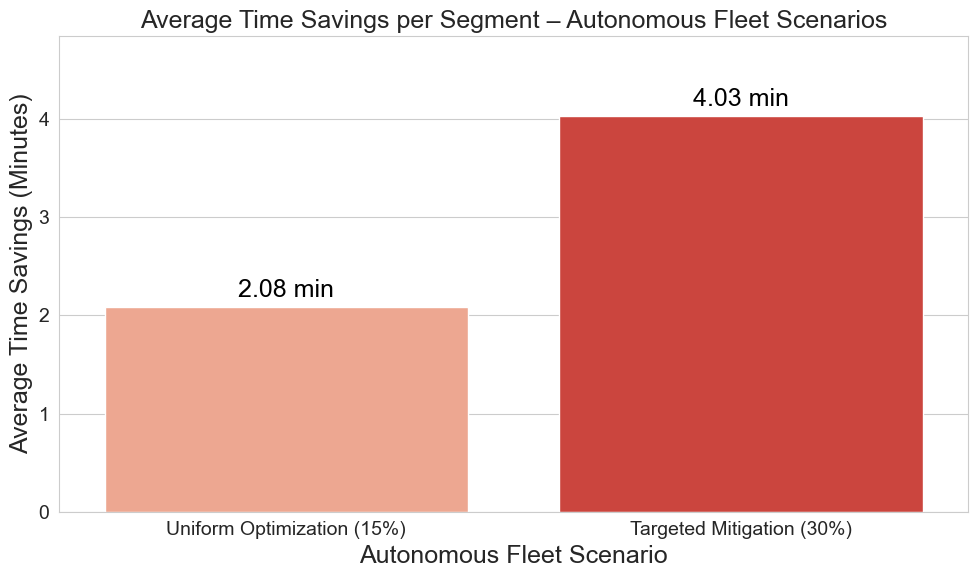

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

def converter_gtfs_tempo(tempo_str):
    return pd.to_timedelta(tempo_str, errors='coerce')

df = pd.read_csv(DATASETS_DIR / "dataset_final_unificado.csv")

df = pd.read_csv(caminho_arquivo)

df['arrival_time_td'] = converter_gtfs_tempo(df['arrival_time'].astype(str))
df['departure_time_td'] = converter_gtfs_tempo(df['departure_time'].astype(str))
df.dropna(subset=['arrival_time_td', 'departure_time_td'], inplace=True)
df.sort_values(by=['trip_id', 'stop_sequence'], inplace=True)
df['prev_departure_time_td'] = df.groupby('trip_id')['departure_time_td'].shift(1)
df['duracao_segmento_seg'] = (df['arrival_time_td'] - df['prev_departure_time_td']).dt.total_seconds()
df_model = df[df['duracao_segmento_seg'] > 0].copy()
df_model.dropna(subset=['duracao_segmento_seg'], inplace=True)

base_date = pd.to_datetime('2000-01-01')
df_model['departure_timestamp'] = base_date + df_model['departure_time_td']
df_model['hour_of_day'] = df_model['departure_timestamp'].dt.hour
df_model['day_of_week'] = df_model['departure_timestamp'].dt.dayofweek

features = [
    'direction_id',
    'stop_sequence',
    'stop_lat',
    'stop_lon',
    'hour_of_day',
    'day_of_week'
]
if df_model['route_id'].dtype == 'object':
    df_model['route_id_encoded'] = df_model['route_id'].astype('category').cat.codes
    features.append('route_id_encoded')
else:
    features.append('route_id')

target = 'duracao_segmento_seg'
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_rf_model = RandomForestRegressor(
    n_estimators=125,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
best_rf_model.fit(X_train, y_train)

y_pred_current = best_rf_model.predict(X_test)

optimization_factor = 0.15
y_pred_autonomous_optimized = y_pred_current * (1 - optimization_factor)
y_pred_autonomous_optimized[y_pred_autonomous_optimized < 0] = 0

severe_optimization_factor = 0.30
y_pred_autonomous_interdiction = np.copy(y_pred_current)
mask_slow_predicted_segments = y_pred_current > np.percentile(y_pred_current, 75)
y_pred_autonomous_interdiction[mask_slow_predicted_segments] *= (1 - severe_optimization_factor)
y_pred_autonomous_interdiction[~mask_slow_predicted_segments] *= (1 - optimization_factor)
y_pred_autonomous_interdiction[y_pred_autonomous_interdiction < 0] = 0

avg_economy_optimized = np.mean(y_pred_current - y_pred_autonomous_optimized)
avg_economy_interdiction = np.mean(y_pred_current - y_pred_autonomous_interdiction)

df_economy = pd.DataFrame({
    'Scenario': ['Uniform Optimization (15%)', 'Targeted Mitigation (30%)'],
    'Average Time Savings (Minutes)': [avg_economy_optimized / 60, avg_economy_interdiction / 60]
})

font_sizes = {
    'title': 18,
    'labels': 18,
    'ticks': 14,
    'legend': 18,
    'annotation': 18
}
sns.set_style("whitegrid")
plt.rc('axes', titlesize=font_sizes['title'])
plt.rc('axes', labelsize=font_sizes['labels'])
plt.rc('xtick', labelsize=font_sizes['ticks'])
plt.rc('ytick', labelsize=font_sizes['ticks'])
plt.rc('legend', fontsize=font_sizes['legend'])
plt.rc('font', size=font_sizes['ticks'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Scenario', y='Average Time Savings (Minutes)', data=df_economy, palette='Reds')
plt.title('Average Time Savings per Segment – Autonomous Fleet Scenarios')
plt.ylabel('Average Time Savings (Minutes)')
plt.xlabel('Autonomous Fleet Scenario')
plt.ylim(0, df_economy['Average Time Savings (Minutes)'].max() * 1.2)

for index, row in df_economy.iterrows():
    plt.text(index, row['Average Time Savings (Minutes)'] + 0.1,
             f"{row['Average Time Savings (Minutes)']:.2f} min",
             color='black', ha="center", fontsize=font_sizes['annotation'])

plt.tight_layout()
plt.savefig("average_time_savings_per_segment.eps", format='eps', dpi=300)
plt.show()

C:\Users\teren\AppData\Local\Temp\ipykernel_25572\2726868393.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Scenario', y='Average Duration (Minutes)', data=df_mean_durations, palette='OrRd_r')


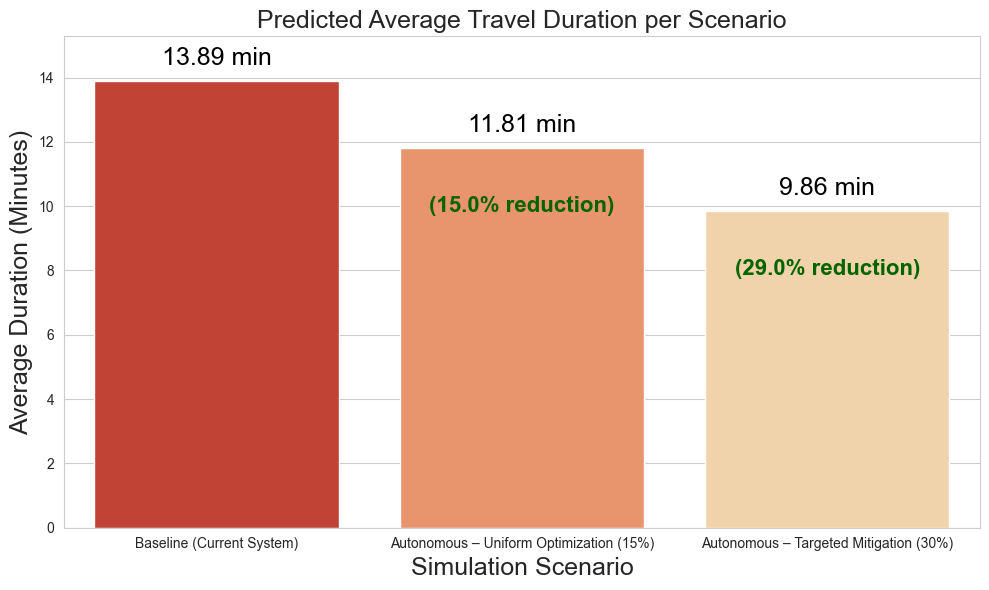

In [ ]:
mean_current_duration = np.mean(y_pred_current) / 60
mean_optimized_duration = np.mean(y_pred_autonomous_optimized) / 60
mean_interdiction_duration = np.mean(y_pred_autonomous_interdiction) / 60

df_mean_durations = pd.DataFrame({
    'Scenario': [
        'Baseline (Current System)',
        'Autonomous – Uniform Optimization (15%)',
        'Autonomous – Targeted Mitigation (30%)'
    ],
    'Average Duration (Minutes)': [
        mean_current_duration,
        mean_optimized_duration,
        mean_interdiction_duration
    ]
})

font_sizes = {
    'title': 18,
    'labels': 18,
    'ticks': 10,
    'legend': 18,
    'annotation': 18,
    'percentage': 16
}
sns.set_style("whitegrid")
plt.rc('axes', titlesize=font_sizes['title'])
plt.rc('axes', labelsize=font_sizes['labels'])
plt.rc('xtick', labelsize=font_sizes['ticks'])
plt.rc('ytick', labelsize=font_sizes['ticks'])
plt.rc('legend', fontsize=font_sizes['legend'])
plt.rc('font', size=font_sizes['ticks'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Scenario', y='Average Duration (Minutes)', data=df_mean_durations, palette='OrRd_r')
plt.title('Predicted Average Travel Duration per Scenario')
plt.ylabel('Average Duration (Minutes)')
plt.xlabel('Simulation Scenario')
plt.ylim(0, df_mean_durations['Average Duration (Minutes)'].max() * 1.1)

for index, row in df_mean_durations.iterrows():

    plt.text(index, row['Average Duration (Minutes)'] + 0.5,
             f"{row['Average Duration (Minutes)']:.2f} min",
             color='black', ha="center", fontsize=font_sizes['annotation'])


    if index > 0:
        reduction_percent = ((mean_current_duration - row['Average Duration (Minutes)']) / mean_current_duration) * 100
        plt.text(index, row['Average Duration (Minutes)'] - 2,
                 f"({reduction_percent:.1f}% reduction)",
                 color='darkgreen', ha="center", fontsize=font_sizes['percentage'], weight='bold')


plt.tight_layout()
plt.savefig("average_duration_per_scenario.eps", format='eps', dpi=300)
plt.show()

ITEM 1.1 — Observed vs Predicted

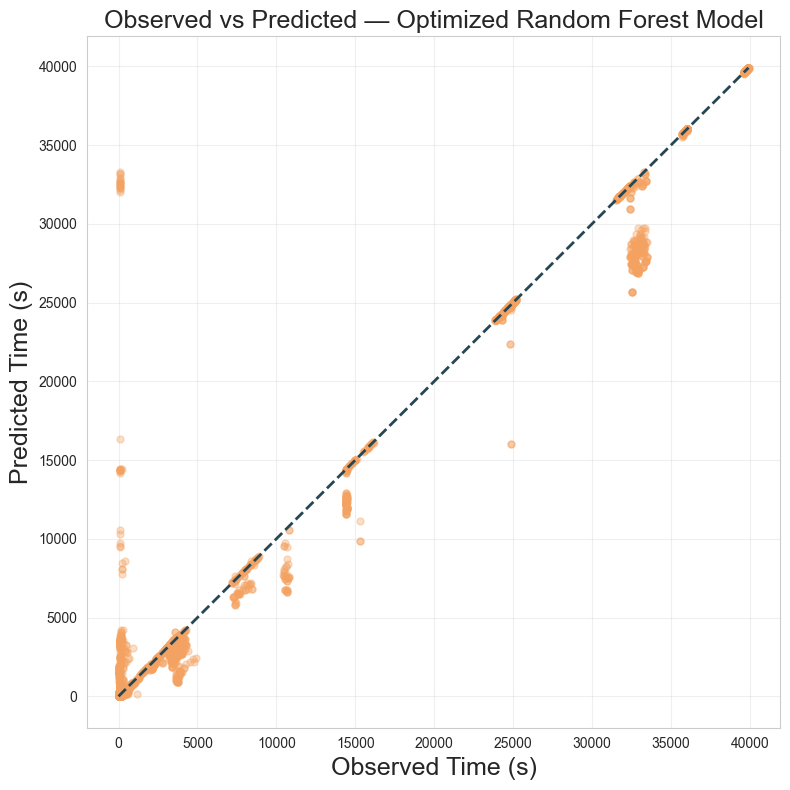

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

y_true = np.array(y_test)
y_pred = np.array(y_pred_current)

plt.figure(figsize=(8, 8))


plt.scatter(
    y_true,
    y_pred,
    alpha=0.35,
    s=25,
    color="#f4a261"
)


min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    linewidth=2,
    color="#264653"
)

plt.xlabel("Observed Time (s)")
plt.ylabel("Predicted Time (s)")
plt.title("Observed vs Predicted — Optimized Random Forest Model")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


ITEM 1.2 — Residual Heatmap

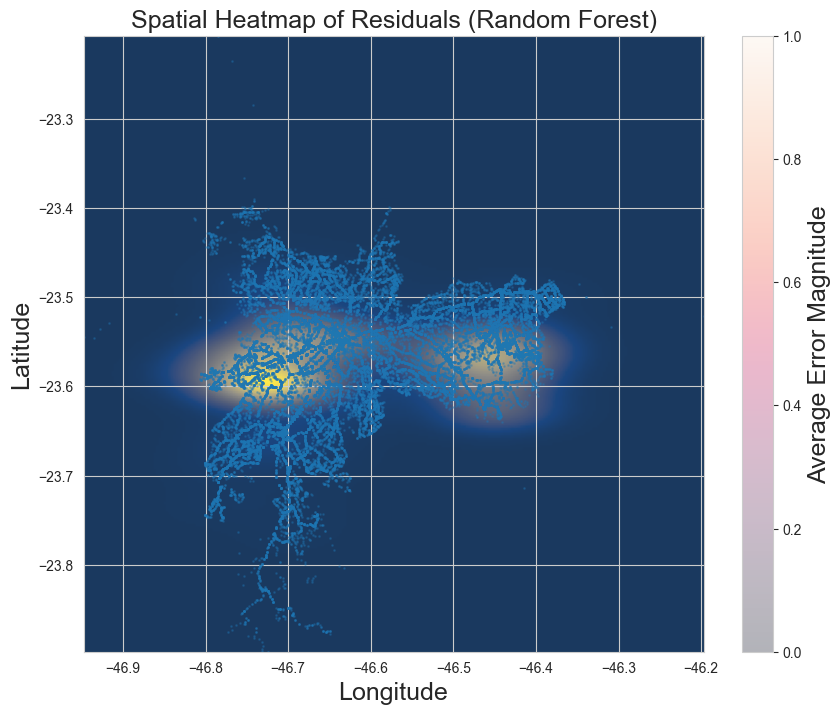

In [ ]:
plt.figure(figsize=(10, 8))

plt.imshow(
    zz,
    cmap='cividis',
    extent=[xmin, xmax, ymin, ymax],
    origin='lower',
    aspect='auto',
    alpha=0.9
)

plt.scatter(lon, lat, s=1, alpha=0.3)
plt.title("Spatial Heatmap of Residuals (Random Forest)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

cbar = plt.colorbar()
cbar.set_label("Average Error Magnitude")

plt.show()

ITEM 2.1. Confidence Intervals (CI) for RMSE and R²

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

def bootstrap_metrics(y_true, y_pred, n_boot=1000, seed=42):
    """
    Calcula intervalos de confiança via bootstrap para RMSE e R².

    Parâmetros
    ----------
    y_true : array-like
        Valores observados.
    y_pred : array-like
        Valores previstos pelo modelo.
    n_boot : int, opcional (default = 1000)
        Número de reamostragens bootstrap.
    seed : int, opcional (default = 42)
        Semente para reprodutibilidade.

    Retorna
    -------
    dict
        {'rmse': valor, 'rmse_ic': (inf, sup),
         'r2': valor,   'r2_ic': (inf, sup)}
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rng = np.random.default_rng(seed)
    n = len(y_true)

    rmse_boot = []
    r2_boot = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)

        yt = y_true[idx]
        yp = y_pred[idx]

        rmse_boot.append(np.sqrt(mean_squared_error(yt, yp)))
        r2_boot.append(r2_score(yt, yp))


    rmse_point = np.sqrt(mean_squared_error(y_true, y_pred))
    r2_point = r2_score(y_true, y_pred)


    rmse_ic = (np.percentile(rmse_boot, 2.5),
               np.percentile(rmse_boot, 97.5))

    r2_ic = (np.percentile(r2_boot, 2.5),
             np.percentile(r2_boot, 97.5))

    return {
        "rmse": rmse_point,
        "rmse_ic": rmse_ic,
        "r2": r2_point,
        "r2_ic": r2_ic
    }


results = bootstrap_metrics(y_test, y_pred_current)

print("---- Intervalos de Confiança (Bootstrap 95%) ----")
print(f"RMSE: {results['rmse']:.2f}  "
      f"(IC 95% = {results['rmse_ic'][0]:.2f}  a  {results['rmse_ic'][1]:.2f})")

print(f"R²:   {results['r2']:.3f}   "
      f"(IC 95% = {results['r2_ic'][0]:.3f}  a  {results['r2_ic'][1]:.3f})")

---- Intervalos de Confiança (Bootstrap 95%) ----
RMSE: 829.94  (IC 95% = 705.74  a  948.44)
R²:   0.963   (IC 95% = 0.951  a  0.974)
